### Data Processing

In [61]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance

In [25]:
seattle = pd.read_csv("listings.csv.gz")
seattle.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [26]:
# turn price into string
seattle["price"] = (
    seattle["price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

In [27]:
# fill null with 0
seattle = seattle.fillna(0)
# filter price <= 0
seattle = seattle[seattle["price"] > 0]
# remove extreme price
p99_seattle = seattle["price"].quantile(0.99)
seattle = seattle[seattle["price"] <= p99_seattle]

### K-NN Classification

#### Features
1. Relative Pricing	
- (price / average pricing) of listings with same conditions (same neighborhood, # of bedrooms and bathrooms, and roomtype)
2. Housing Characteristics:
Room Type 
- num of Bedrooms 
- num of Bathrooms 
- num of Beds 
- num of Accommodates 
- Neighborhood
- Minimum Nights
    - (short term stays vs. long term stays): Distribution
3. Host Characteristics:
- Host_Response TIme
- Host Is Superhost
- Superhost / Host (Verified) / Host (Unverified)
4. Other Users Experience:
- num of Reviews
- num of Reviews Last Twelve Month
- num of Review Last 30 Days


In [28]:
# create relative price columns
# Relative Pricing =  Pricing / Mean Pricing of listings with same neighborhood, # of bedrooms and bathrooms, and roomtype
group_cols = ["bedrooms", "bathrooms", "neighbourhood_cleansed", "room_type"]
seattle["avg_price_group"] = seattle.groupby(group_cols)["price"].transform("mean")
seattle["relative_price"] = seattle["price"] / seattle["avg_price_group"]

In [29]:
features = [
    # relative pricing
    "relative_price",
    # housing characteristics
    "bedrooms",
    "beds",
    "bathrooms",
    "accommodates",
    "neighbourhood",
    "minimum_nights",
    "room_type",
    # host characteristics
    "host_response_time",
    "host_is_superhost", 
    # others
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d"
]

In [30]:
df_sea = seattle[features]
df_sea = df_sea.fillna(0)
df_sea

,relative_price,bedrooms,beds,bathrooms,accommodates,neighbourhood,minimum_nights,room_type,host_response_time,host_is_superhost,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d
0,0.772909,1.0,1.0,1.0,1,Neighborhood highlights,30,Entire home/apt,within a few hours,t,161,0,0
1,0.984592,1.0,2.0,3.0,2,Neighborhood highlights,2,Private room,within an hour,t,220,14,1
3,1.232497,3.0,3.0,2.0,8,0,30,Entire home/apt,within a few hours,t,98,0,0
4,0.741860,1.0,2.0,1.0,4,Neighborhood highlights,2,Entire home/apt,within an hour,t,1139,62,3
5,0.969773,2.0,3.0,1.0,3,Neighborhood highlights,30,Entire home/apt,within a few hours,f,64,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6991,1.091398,1.0,1.0,1.5,2,0,1,Private room,0,f,0,0,0
6992,1.091398,1.0,1.0,1.5,2,0,1,Private room,0,f,0,0,0
6993,1.000000,1.0,1.0,1.0,2,0,3,Private room,within a few hours,f,0,0,0
6994,1.073869,1.0,1.0,1.0,2,0,30,Entire home/apt,0,f,0,0,0


#### Training Model

In [40]:
# target variable: review_score_rating
## high v.s. low score: scores >= 4.9
y = (seattle["review_scores_rating"] >= 4.9).astype(int)

In [50]:
y.value_counts()

review_scores_rating
0    3327
1    2831
Name: count, dtype: int64

In [41]:
X = pd.get_dummies(df_sea, drop_first = True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
X.head()

,relative_price,bedrooms,beds,bathrooms,accommodates,minimum_nights,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,neighbourhood_Neighborhood highlights,room_type_Private room,room_type_Shared room,host_response_time_a few days or more,host_response_time_within a day,host_response_time_within a few hours,host_response_time_within an hour,host_is_superhost_f,host_is_superhost_t
0,0.772909,1.0,1.0,1.0,1,30,161,0,0,True,False,False,False,False,True,False,False,True
1,0.984592,1.0,2.0,3.0,2,2,220,14,1,True,True,False,False,False,False,True,False,True
3,1.232497,3.0,3.0,2.0,8,30,98,0,0,False,False,False,False,False,True,False,False,True
4,0.741860,1.0,2.0,1.0,4,2,1139,62,3,True,False,False,False,False,False,True,False,True
5,0.969773,2.0,3.0,1.0,3,30,64,0,0,True,False,False,False,False,True,False,True,False


#### Deciding k-values

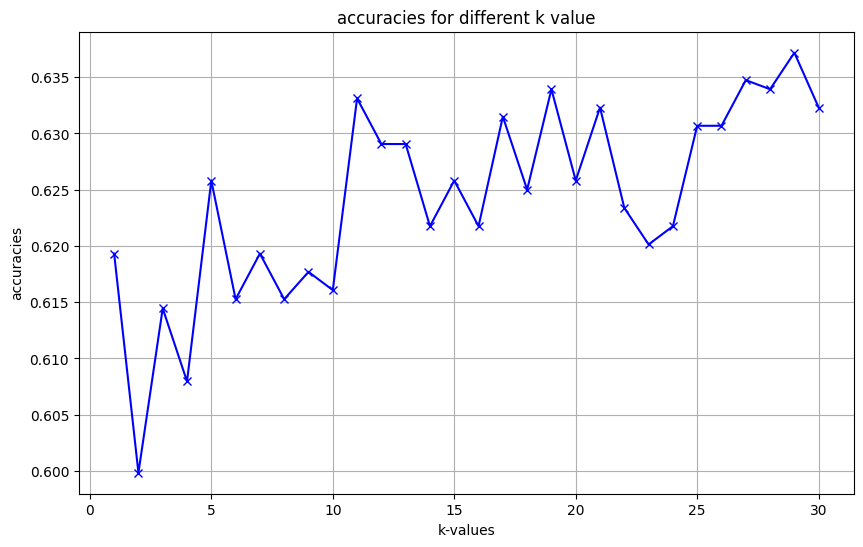

In [47]:
k_values = range(1, 31)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    accuracies.append(acc)

# data viz
x = np.arange(1,31)
plt.figure(figsize=(10, 6))
plt.plot(x, accuracies, 'bx-')
plt.xlabel('k-values')
plt.ylabel('accuracies')
plt.title('accuracies for different k value')
plt.grid(True)
plt.show()

#### Model Performance

In [59]:
clf = KNeighborsClassifier(n_neighbors=29)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# Calculate precision
precision = precision_score(y_test, y_pred)

# Evaluate the model
print("\nAccuracy:")
print(clf.score(X_test, y_test))
print("\nPrecision Score:")
print(precision)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy:
0.6371753246753247

Precision Score:
0.5924006908462867

Confusion Matrix:
[[442 236]
 [211 343]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.65      0.66       678
           1       0.59      0.62      0.61       554

    accuracy                           0.64      1232
   macro avg       0.63      0.64      0.63      1232
weighted avg       0.64      0.64      0.64      1232



### Feature Importance
- K-NN doesn't have feature importance function since it's not tree-based model, so I use `Permutation Importance` instead
- Concept: Measures how much the model's performance drops when a feature is randomly shuffled, if the performance drops significantly then the feature can be seen as important
- ref: https://github.com/scikit-learn/scikit-learn/discussions/28304

In [71]:
# Calculate permutation importance
result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42)

# result.importances_mean contains the importance scores
importances = pd.DataFrame({
    "feature_names": X.columns,
    "Importance": result.importances_mean
}).sort_values("Importance", ascending = False)
importances.head(10)

,feature_names,Importance
7,number_of_reviews_ltm,0.124513
6,number_of_reviews,0.061364
5,minimum_nights,0.020292
4,accommodates,0.019562
8,number_of_reviews_l30d,0.014692
2,beds,0.010308
1,bedrooms,0.006250
3,bathrooms,0.005032
17,host_is_superhost_t,0.003815
16,host_is_superhost_f,0.003247


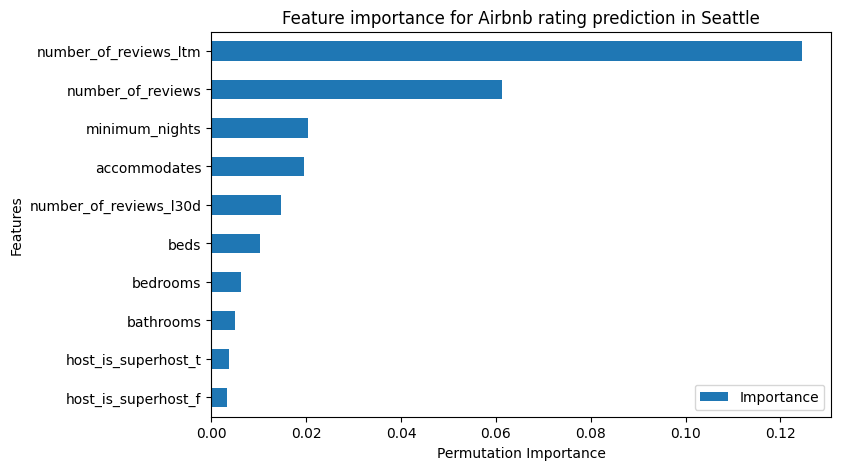

In [73]:
# data viz
importances.head(10).plot(
    x="feature_names",
    y="Importance",
    kind="barh",
    figsize=(8, 5)
)
plt.title("Feature importance for Airbnb rating prediction in Seattle")
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()